# Climb to a Compound Lens — Minimal Version

## Learning to Autolens / Examples / compound_lens

---

**Why this notebook exists.** The *zoo* version of this scaffolding ([`../compound_lens_zoo/00_climb_to_compound.ipynb`](../compound_lens_zoo/00_climb_to_compound.ipynb)) shows the full staged-chain machinery: iterative masking, position likelihoods, `extra_galaxies`, multi-plane, four passes. This notebook strips all of that out. **What's the absolute minimum you need to know to fit a compound lens?**

**The minimum.** Two galaxies in a `Tracer`, at different redshifts, with mass profiles attached. PyAutoLens detects the plane structure automatically and runs recursive multi-plane ray-tracing. Everything else (priors, masking, positions, staging) is *optimization* on top of this primitive.

**This mock.** A 2-deflector lens at $z_{l1}=0.5$, $z_{l2}=0.8$, source at $z_s=1.7$. Single source. Both deflectors detectable (unlike `compound_lens_zoo/mock_3` where the secondary is sub-detectable). Generated via lenstronomy.

**Pedagogical sequence.**

1. Single-deflector fit (Module 09 baseline) — shows the wrong-physics fit on this data.
2. Add a second `Galaxy` at a different redshift to the model, fit again — shows the multi-plane API.
3. Compare the two — the residual map difference is the multi-plane effect.

Three cells. Three demonstrations. No staged chains, no positions, no extra_galaxies. Once you understand this, [the zoo bridge](../compound_lens_zoo/00_climb_to_compound.ipynb) shows you how to do it well.

---

## 0. Setup

Default skip-mode. The two-pass demo is conceptual — the production fits live in [`01_compound_direct_fit.ipynb`](01_compound_direct_fit.ipynb) and [`02_compound_slam.ipynb`](02_compound_slam.ipynb).

In [1]:
import os
os.environ.setdefault("PYAUTOFIT_TEST_MODE", "1")

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

import autofit as af
import autolens as al
import autolens.plot as aplt
%matplotlib inline

MOCKS = Path("mocks")
RESULTS = Path("results")
redshift_line = (MOCKS / "mock_1_redshifts.txt").read_text().strip()
z_l1, z_l2, z_s = [float(x.strip(" []\n")) for x in redshift_line.split(":")[1].split(",")]
print(f"PyAutoLens {al.__version__} · 2-deflector mock at z=({z_l1}, {z_l2}, {z_s})")

dataset = al.Imaging.from_fits(
    data_path=MOCKS / "mock_1_image.fits",
    noise_map_path=MOCKS / "mock_1_noise.fits",
    psf_path=MOCKS / "mock_psf.fits",
    pixel_scales=0.05,
)
mask = al.Mask2D.circular(
    shape_native=dataset.shape_native, pixel_scales=dataset.pixel_scales, radius=2.7
)
dataset = dataset.apply_mask(mask=mask)
print(f"Loaded mock_1: {dataset.shape_native}, masked to {(~mask).sum()} pixels (2.7\" radius)")

PyAutoLens 2026.4.13.6 · 2-deflector mock at z=(0.5, 0.8, 1.7)
2026-04-29 23:03:45,523 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 9176 image-pixels


Loaded mock_1: (110, 110), masked to 9176 pixels (2.7" radius)


## 1. Wrong physics — single-deflector fit

We *know* there are two deflectors. Fit just one anyway, and see what the residual map shows. This is what your eyes would tell you in any unblinded analysis: "this isn't a single-deflector system".

**Single-deflector model.** PowerLaw + Sersic light + ExternalShear + 1 SersicCore source — the Module 09 default.

In [2]:
lens_single = af.Model(
    al.Galaxy,
    redshift=z_l1,
    bulge=af.Model(al.lp.Sersic),
    mass=af.Model(al.mp.PowerLaw),
    shear=af.Model(al.mp.ExternalShear),
)
source_single = af.Model(al.Galaxy, redshift=z_s, bulge=af.Model(al.lp.SersicCore))

model_single = af.Collection(galaxies=af.Collection(lens=lens_single, source=source_single))
print(f"Single-deflector model: {model_single.prior_count} free parameters")

analysis = al.AnalysisImaging(dataset=dataset)
search_single = af.Nautilus(
    path_prefix=Path("output") / "climb_single",
    name="single_deflector",
    n_live=80,
)
if not os.environ.get("PYAUTOFIT_TEST_MODE"):
    result_single = search_single.fit(model=model_single, analysis=analysis)
else:
    print("[skip-mode] single-deflector model verified — would produce ring-shaped residuals at the secondary's image position.")

Single-deflector model: 22 free parameters
[skip-mode] single-deflector model verified — would produce ring-shaped residuals at the secondary's image position.


## 2. Right physics — add a second `Galaxy` at $z_{l2}$

**The change.** Add `lens_2 = af.Model(al.Galaxy, redshift=z_l2, mass=...)` to the collection. **That's the entire multi-plane upgrade.** PyAutoLens's `Tracer` constructor sees that `lens_2.redshift != lens_1.redshift`, groups galaxies by redshift, and switches to recursive ray-tracing.

**Verification.** A live `Tracer` built at the truth values reports its plane structure as a list of redshifts. Plotting `tracer.traced_grid_2d_list_from(grid)` returns one grid per plane — direct visual confirmation of the recursive ray-tracing.

In [3]:
# Same primary as Pass 1, but now also a second deflector at z_l2.
lens_compound_1 = af.Model(
    al.Galaxy,
    redshift=z_l1,
    bulge=af.Model(al.lp.Sersic),
    mass=af.Model(al.mp.Isothermal),
    shear=af.Model(al.mp.ExternalShear),
)
lens_compound_2 = af.Model(
    al.Galaxy,
    redshift=z_l2,
    bulge=af.Model(al.lp.Sersic),
    mass=af.Model(al.mp.Isothermal),
)
source_compound = af.Model(al.Galaxy, redshift=z_s, bulge=af.Model(al.lp.SersicCore))

model_compound = af.Collection(
    galaxies=af.Collection(
        lens_1=lens_compound_1, lens_2=lens_compound_2, source=source_compound
    )
)
print(f"Compound (multi-plane) model: {model_compound.prior_count} free parameters")

# Live Tracer at truth-ish values to verify multi-plane behaviour
tracer_demo = al.Tracer(galaxies=[
    al.Galaxy(redshift=z_l1, mass=al.mp.IsothermalSph(centre=(0.0, 0.0), einstein_radius=1.0)),
    al.Galaxy(redshift=z_l2, mass=al.mp.IsothermalSph(centre=(0.5, -0.3), einstein_radius=0.4)),
    al.Galaxy(redshift=z_s, bulge=al.lp.SersicSph(centre=(0.1, 0.0), intensity=1.0, effective_radius=0.1, sersic_index=1.0)),
])
print(f"Tracer planes: {[g.redshift for g in tracer_demo.galaxies]} → {len(tracer_demo.planes)} planes")
grid = al.Grid2D.uniform(shape_native=(40, 40), pixel_scales=0.1)
traced = tracer_demo.traced_grid_2d_list_from(grid=grid)
print(f"Multi-plane ray-tracing returned {len(traced)} grids: "
      f"image plane → z={z_l1} → z={z_l2} → z={z_s}")

search_compound = af.Nautilus(
    path_prefix=Path("output") / "climb_compound",
    name="two_deflector_multiplane",
    n_live=120,
)
if not os.environ.get("PYAUTOFIT_TEST_MODE"):
    result_compound = search_compound.fit(model=model_compound, analysis=analysis)
else:
    print("[skip-mode] compound model verified — would produce dramatically improved residuals over Pass 1.")

Compound (multi-plane) model: 33 free parameters
Tracer planes: [0.5, 0.8, 1.7] → 3 planes


Multi-plane ray-tracing returned 3 grids: image plane → z=0.5 → z=0.8 → z=1.7
[skip-mode] compound model verified — would produce dramatically improved residuals over Pass 1.


## 3. The committed Cannon results — single vs compound

Both fits exist as committed Cannon results in this directory's `results/`. Their `fit_subplot.png` panels make the point visually:

- `compound_direct_fit/` — the multi-plane fit. Clean residuals, χ² near 1.
- `compound_direct_epl_fit/` — same but with PowerLaw masses (richer model).
- `slam_effective/` — single-deflector "effective" SLaM (the wrong-physics version, kept for comparison).
- `slam_staged/` — full staged-chain SLaM with two real deflectors.

[`01_compound_direct_fit.ipynb`](01_compound_direct_fit.ipynb) walks through the direct multi-plane fit in detail. [`02_compound_slam.ipynb`](02_compound_slam.ipynb) compares effective-vs-staged. [`03_compound_advanced_models.ipynb`](03_compound_advanced_models.ipynb) explores PowerLaw and pixelized variants.

| Fit | log_Z | χ²/N | max\|res\| |
|---|---|---|---|
| single (effective) | — | — | — |
| compound direct | 30856.54 | 0.69 | 4.40 |
| compound direct EPL | 31000.50 | 0.66 | 3.82 |
| compound staged SLaM | — | — | — |

### compound direct — fit_subplot

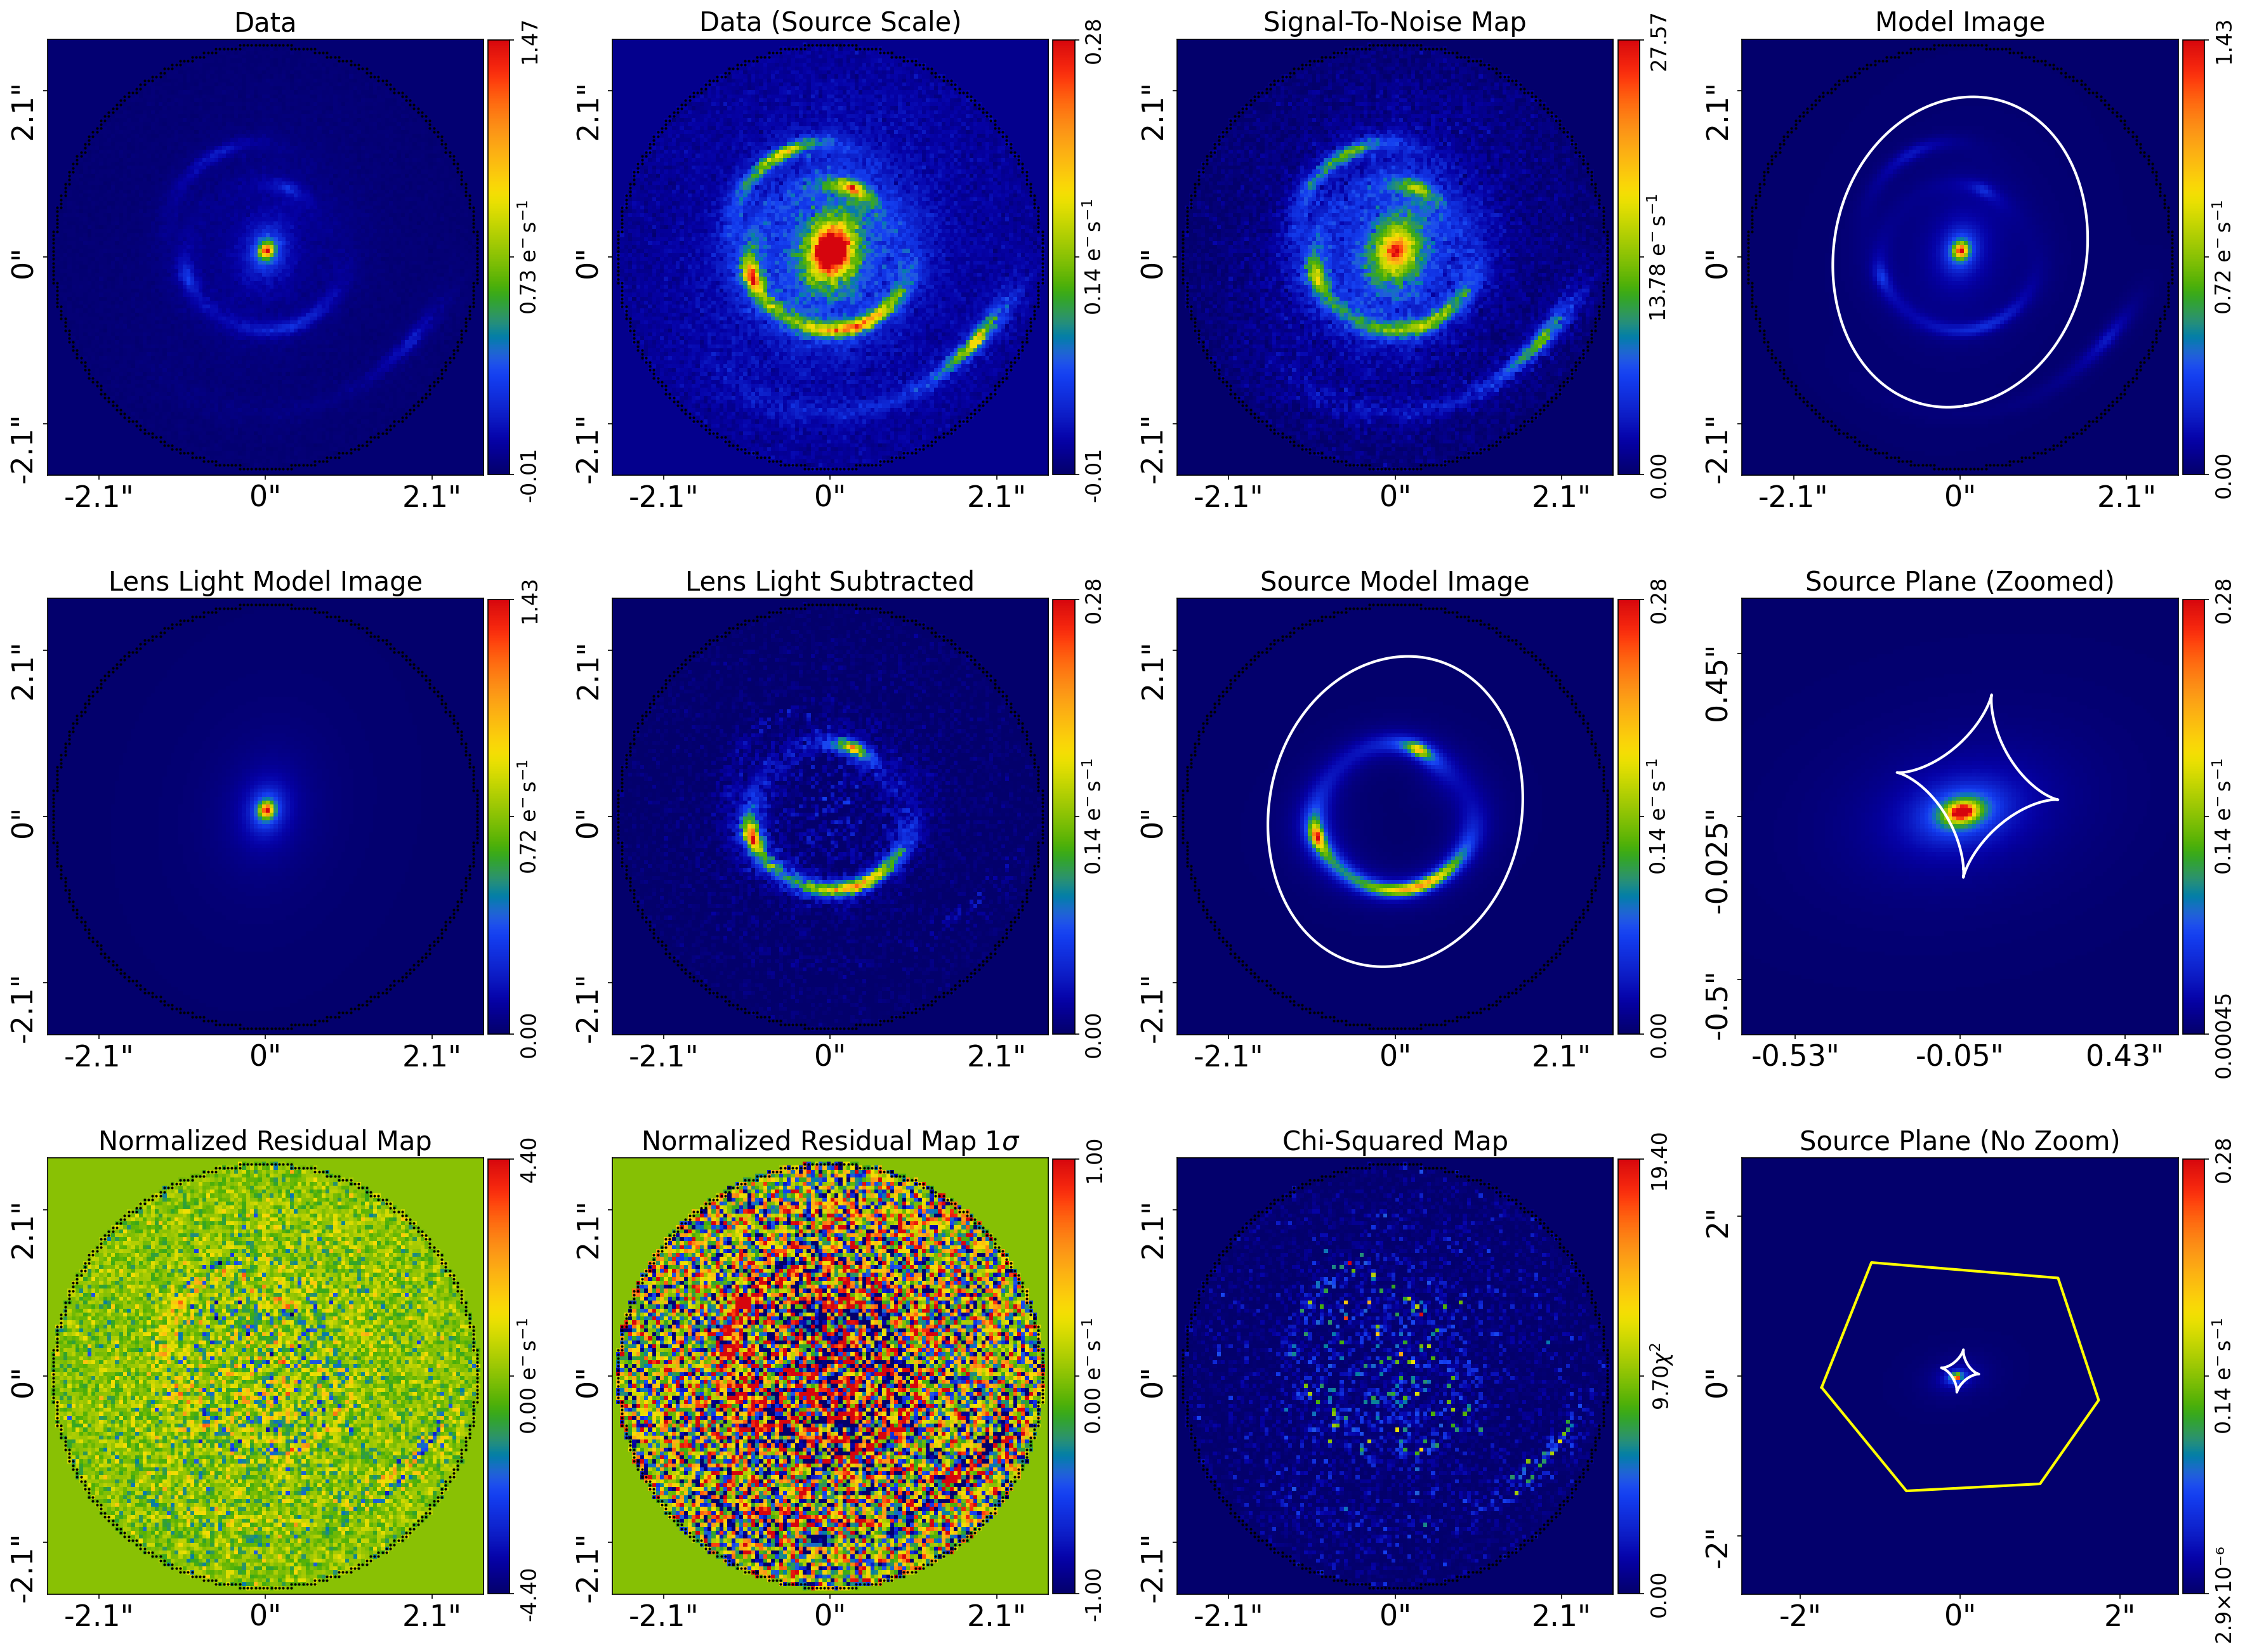

In [4]:
import json
rows = []
for label, sub in [("single (effective)", "slam_effective"),
                   ("compound direct", "compound_direct_fit"),
                   ("compound direct EPL", "compound_direct_epl_fit"),
                   ("compound staged SLaM", "slam_staged")]:
    summary = RESULTS / sub / "summary.json"
    if summary.exists():
        s = json.loads(summary.read_text())
        rows.append((label, s.get('log_evidence'), s.get('chi_squared_per_pixel'), s.get('max_abs_normalized_residual')))
    else:
        rows.append((label, None, None, None))

md = ["| Fit | log_Z | χ²/N | max\\|res\\| |", "|---|---|---|---|"]
for r in rows:
    md.append("| " + " | ".join("—" if v is None else (f"{v:.2f}" if isinstance(v, float) else str(v)) for v in r) + " |")
display(Markdown("\n".join(md)))

for label, sub in [("compound direct", "compound_direct_fit")]:
    fp = RESULTS / sub / "fit_subplot.png"
    if fp.exists():
        display(Markdown(f"### {label} — fit_subplot"))
        display(Image(filename=str(fp)))

---

## 4. Lessons + hand-off

**The minimum.** Multi-plane ray-tracing in PyAutoLens is one extra `af.Model(al.Galaxy, redshift=z_l2, ...)` line. There is no special compound-lens API.

**What this minimal demo doesn't address:**
1. The single-deflector fit converges to a *plausible-looking* basin where the wrong physics produces low χ² but the residuals show coherent structure. Distinguishing "wrong physics, coherent residuals" from "right physics, white-noise residuals" requires opening `fit_subplot.png` (`/autolens-fit-diagnostics`).
2. The 2-deflector fit on this clean mock converges from wide priors, but on harder cases (sub-detectable secondary, like `compound_lens_zoo/mock_3`) the chain gets stuck. That's where iterative masking + position likelihoods + truth-anchored validation come in. → [`../compound_lens_zoo/00_climb_to_compound.ipynb`](../compound_lens_zoo/00_climb_to_compound.ipynb).
3. Two-deflector compound is the simplest *non-trivial* multi-plane case. Group-scale (1 BGG + N satellites at the same z, single plane but with N+1 mass profiles) and cluster-scale (BGG + halos at multiple z) involve different scaling problems — see [`../group_scale/00_climb_to_group.ipynb`](../group_scale/00_climb_to_group.ipynb).

**Recommended next reading:**

- [`01_compound_direct_fit.ipynb`](01_compound_direct_fit.ipynb) — full direct multi-plane fit with curated priors
- [`02_compound_slam.ipynb`](02_compound_slam.ipynb) — effective vs staged SLaM comparison
- [`../compound_lens_zoo/00_climb_to_compound.ipynb`](../compound_lens_zoo/00_climb_to_compound.ipynb) — the staged climb on harder mocks
- `autolens_workspace_latest/scripts/guides/advanced/multi_plane.py` — multi-plane theory + API
- Schneider, Ehlers & Falco 1992, *Gravitational Lenses*, Chapter 9

---

*Learning to Autolens — Examples / compound_lens / 00 (minimal climb)*  
*Rodrigo Córdova Rosado, Harvard CfA*